In [ ]:
from astropy.io import ascii, fits
from astropy.table import Table
TAB = Table(ascii.read('test_for_sed.csv'))
ROW = TAB[0]
FILE = 'test002_fit.h5'


from prospect.io import read_results as pread
# from run_prosp_nonparaSFH import build_model, build_sps
results, observations_dict, _ = pread.results_from(FILE)

In [2]:
import numpy as np
from prospect.io import write_results as writer
from prospect.fitting import fit_model
import sys, os
from astropy.io import ascii
from astropy.table import Table
import helper
from glob import glob
from astropy.constants import c as speedoflight

#------------------------
# Convienence Functions
#------------------------

def tie_gas_logz(logzsol=None, **extras):
    return logzsol

def find_nearest(array,value):
    idx = (np.abs(np.array(array)-value)).argmin()
    return idx

def zfrac_to_masses_log(logmass=None, z_fraction=None, agebins=None, **extras):
    sfr_fraction = np.zeros(len(z_fraction) + 1)
    sfr_fraction[0] = 1.0 - z_fraction[0]
    for i in range(1, len(z_fraction)):
        sfr_fraction[i] = np.prod(z_fraction[:i]) * (1.0 - z_fraction[i])
    sfr_fraction[-1] = 1 - np.sum(sfr_fraction[:-1])
    # convert to mass fractions
    time_per_bin = np.diff(10**agebins, axis=-1)[:, 0]
    mass_fraction = sfr_fraction * np.array(time_per_bin)
    mass_fraction /= mass_fraction.sum()

    if (mass_fraction < 0).any():
        idx = mass_fraction < 0
        if np.isclose(mass_fraction[idx],0,rtol=1e-8):
            mass_fraction[idx] = 0.0
        else:
            raise ValueError('The input z_fractions are returning negative masses!')

    masses = 10**logmass * mass_fraction
    return masses

In [3]:
def build_model(row,**kwargs):
    from prospect.models import priors, sedmodel
    from astropy.cosmology import Planck18 as cosmo
    print('building model')
    model_params = []
    #basics
    zred = row['z']
    lumdist = cosmo.luminosity_distance(zred).value

    model_params.append({'name': "lumdist", "N": 1, "isfree": False,"init": lumdist,"units": "Mpc"})
    model_params.append({'name': 'imf_type', 'N': 1,'isfree': False,'init': 2})
    model_params.append({'name': 'dust_type', 'N': 1,'isfree': False,'init': 2,'prior': None})
    model_params.append({'name': 'dust2', 'N': 1,'isfree': True, 'init': 0.1,'prior': priors.ClippedNormal(mini=-0.3, maxi=0.3, mean=0.0, sigma=0.3)})
    model_params.append({'name': 'add_dust_emission', 'N': 1,'isfree': False,'init': 1,'prior': None})
    model_params.append({'name': 'duste_gamma', 'N': 1,'isfree': True,'init': 0.01,'prior': priors.TopHat(mini=0, maxi=1.0)})
    model_params.append({'name': 'duste_umin', 'N': 1,'isfree': True,'init': 1.0,'prior': priors.TopHat(mini=-10, maxi=20.0)})
    model_params.append({'name': 'duste_qpah', 'N': 1,'isfree': True,'init': 3.0,'prior': priors.TopHat(mini=0, maxi=2)})                                                          
    model_params.append({'name': 'add_agb_dust_model', 'N': 1,'isfree': False,'init': 0})
    
    #M-Z
    model_params.append({'name': 'logmass', 'N': 1,'isfree': True,'init': 10,'prior': priors.Uniform(mini=9, maxi=11)})
    model_params.append({'name': 'logzsol', 'N': 1,'isfree': True,'init': -0.5,'prior': priors.Uniform(mini=-2.2, maxi=-1.2)})
    

    #SFH 
    #here, we tell fsps (via Prospector) that we will be using a special SFH (so init=3, which corresponds to a
    #'custom' SFH). Of note is that the "mass" parameter no long refers to the total stellar mass. Instead,
    #this is related to the stellar mass formed in each piece-wise time bin. However, the model doesn't actually
    #sample the mass posteriors. Instead, it uses a proxy variable "z_fraction" that is related to the choice of
    #prior (Dirichlet distribution). If you want to learn more, I'd highly recommend reading Joel Leja's 2019
    #paper introducing the Prospector non parametric SFH models
    model_params.append({'name': "sfh", "N": 1, "isfree": False, "init": 3})
    #Now, mass refers to the stellar mass formed *in each time bin* while the logmass parameter above 
    #sets the overall normalization 
    model_params.append({'name': "mass", 'N': 3, 'isfree': False, 'init': 1., 'depends_on':zfrac_to_masses_log})
    #agebins are the limits for each piece-wise bin of star formation. these are set below
    model_params.append({'name': "agebins", 'N': 1, 'isfree': False,'init': []})
    #proxy parameter for SFR in each age bin
    model_params.append({'name': "z_fraction", "N": 2, 'isfree': True, 'init': [0, 0],'prior': priors.Beta(alpha=1.0, beta=1.0, mini=0.0, maxi=5.0)})                                                                                                                                                                                                                           

    #NEBULAR STUFF
    ###### Nebular Emission ###########
    model_params.append({'name': 'add_neb_emission', 'N': 1,
                            'isfree': False,
                            'init': True,
                            'units': r'log Z/Z_\odot',
                            'prior_function_name': None,
                            'prior_args': None})

    model_params.append({'name': 'add_neb_continuum', 'N': 1,
                            'isfree': False,
                            'init': True,
                            'units': r'log Z/Z_\odot',
                            'prior_function_name': None,
                            'prior_args': None})
                            
    model_params.append({'name': 'nebemlineinspec', 'N': 1,
                            'isfree': False,
                            'init': False,
                            'prior_function_name': None,
                            'prior_args': None})

    model_params.append({'name': 'gas_logz', 'N': 1,
                            'isfree': True,
                            'init': 0.0,
                            'depends_on': tie_gas_logz,
                            'units': r'log Z/Z_\odot',
                            'prior': priors.TopHat(mini=-3.0, maxi=1)})

    model_params.append({'name': 'gas_logu', 'N': 1,
                            'isfree': True,
                            'init': -2.0,
                            'units': '',
                            'prior': priors.TopHat(mini=-5.0, maxi=-.5)})


    #here we set the number and location of the timebins, and edit the other SFH parameters to match in size
    n = [p['name'] for p in model_params]
    tuniv = 14. #Gyr, age at z=0                                                                                                                                                                                                         
    nbins=10
    tbinmax = (tuniv * 0.8) * 1e9 #earliest time bin goes from age = 0 to age = 2.8 Gyr
    lim1, lim2 = 7.47, 8.0 #most recent time bins at 30 Myr and 100 Myr ago                                                                                                                                                                                                 
    agelims = [0,lim1] + np.linspace(lim2,np.log10(tbinmax),nbins-2).tolist() + [np.log10(tuniv*1e9)]
    agebins = np.array([agelims[:-1], agelims[1:]])

    zinit = np.array([(i-1)/float(i) for i in range(nbins, 1, -1)])
    # Set up the prior in `z` variables that corresponds to a dirichlet in sfr
    # fraction. 
    alpha = np.arange(nbins-1, 0, -1)
    zprior = priors.Beta(alpha=alpha, beta=np.ones_like(alpha), mini=0.0, maxi=1.0)

    model_params[n.index('mass')]['N'] = nbins
    model_params[n.index('agebins')]['N'] = nbins
    model_params[n.index('agebins')]['init'] = agebins.T
    model_params[n.index('z_fraction')]['N'] = nbins-1
    model_params[n.index('z_fraction')]['init'] = zinit
    model_params[n.index('z_fraction')]['prior'] = zprior

    #### now deal with emission lines ####

    model = sedmodel.SedModel(model_params)
    

    return model

model = build_model(ROW)


building model


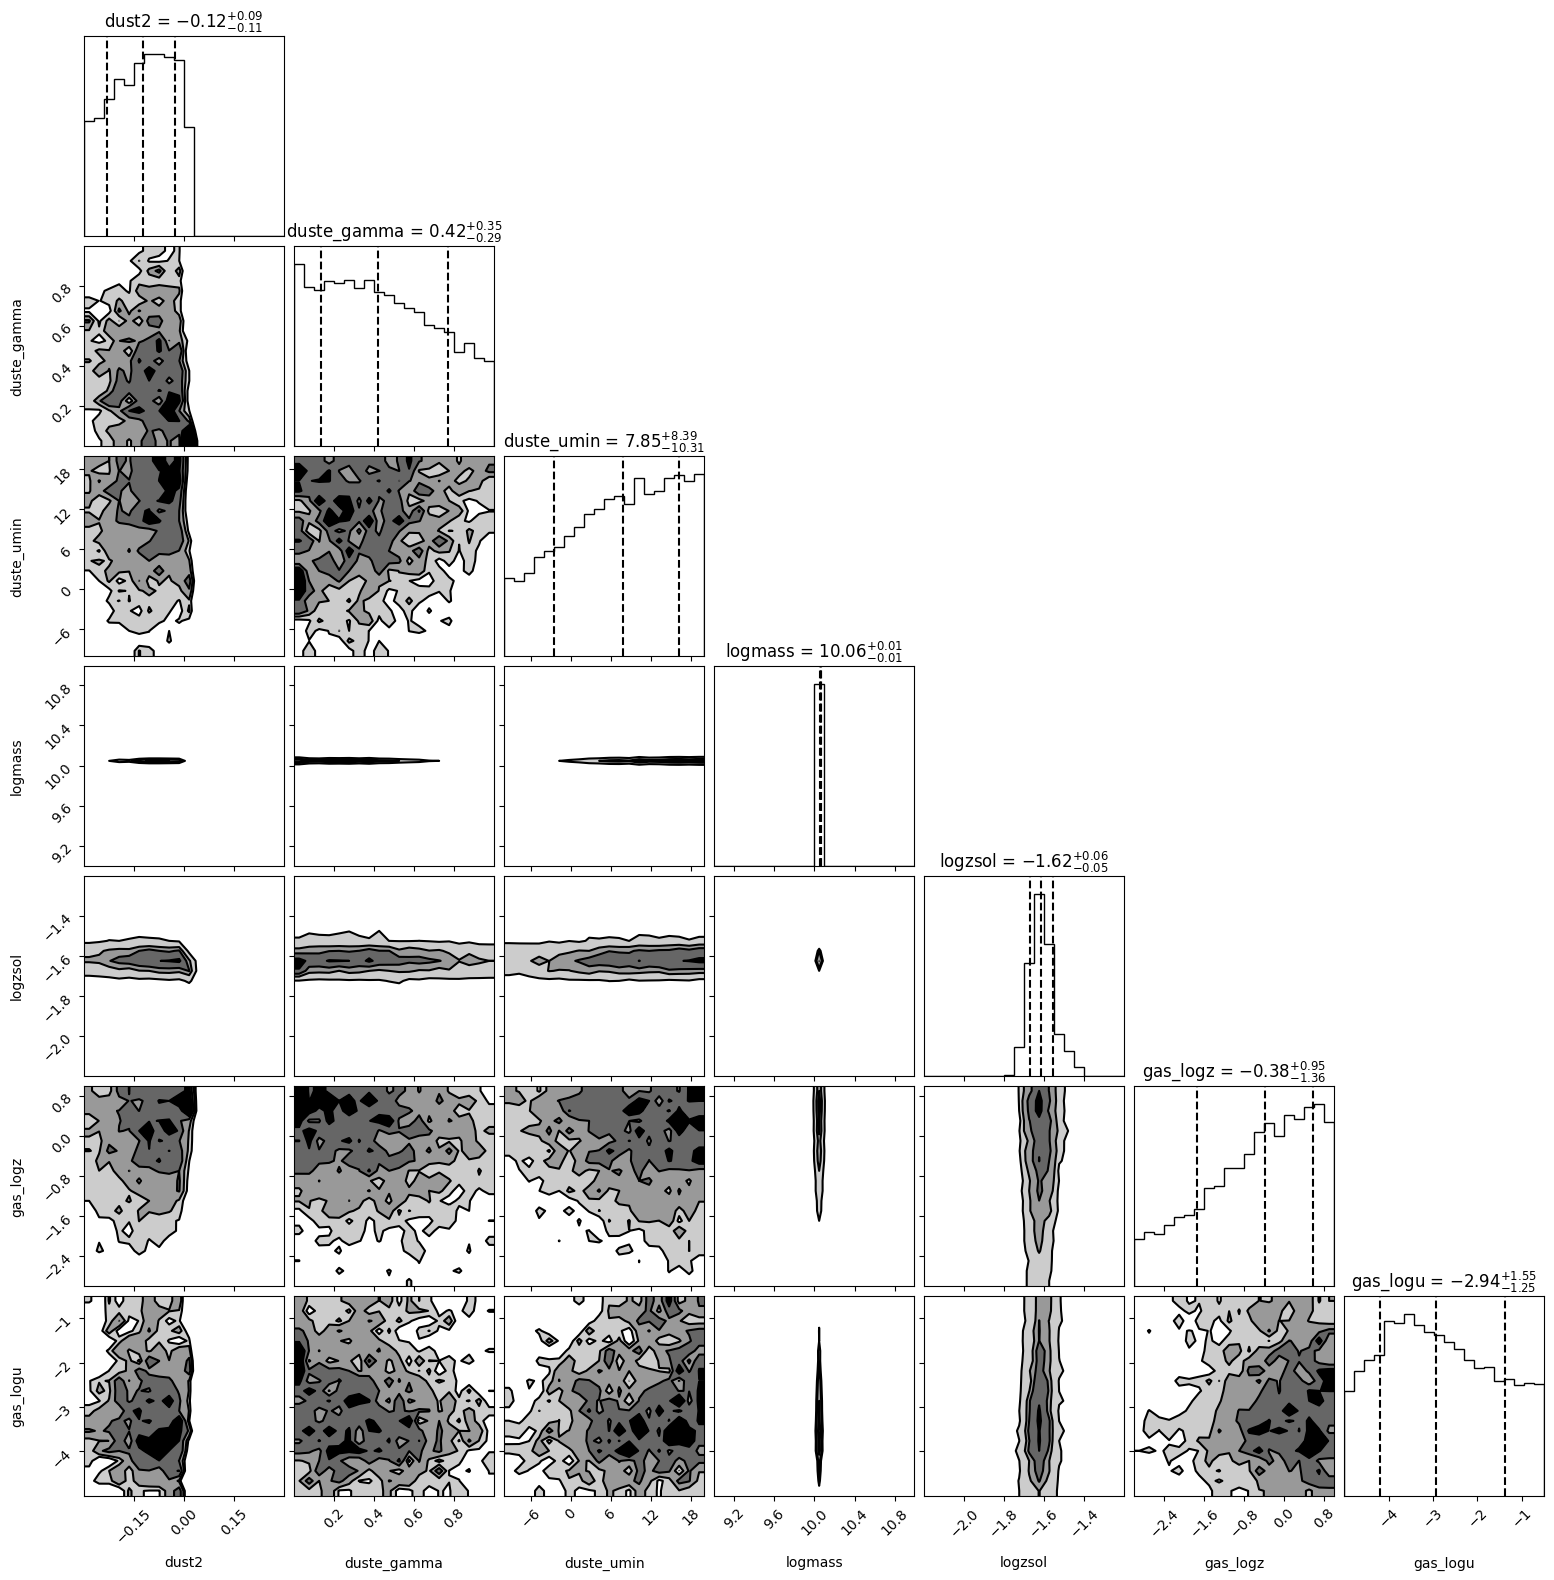

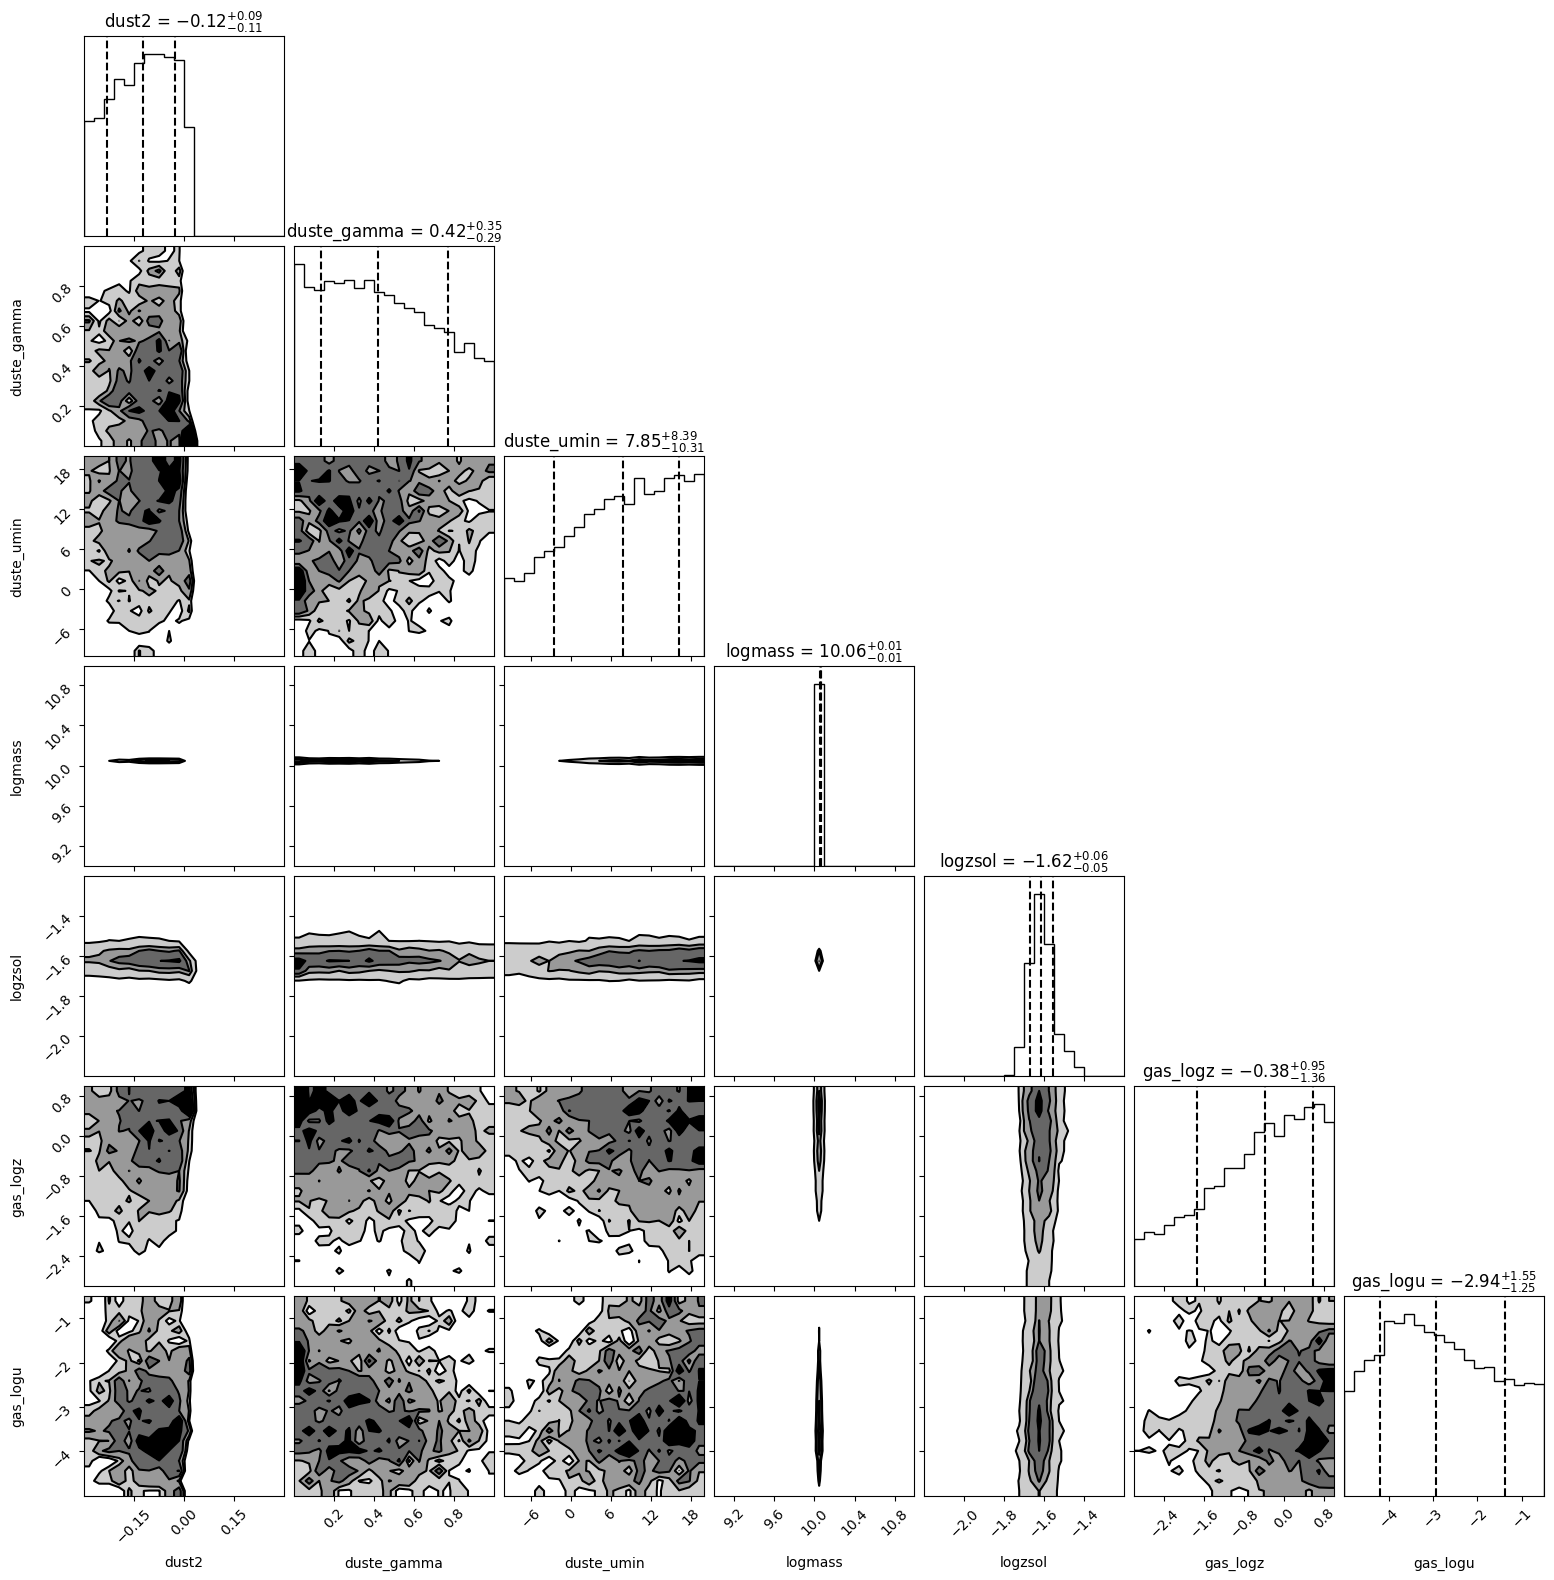

In [4]:
pread.subcorner(results, showpars=['dust2','duste_gamma','duste_umin','logmass','logzsol','gas_logz','gas_logu'])

In [5]:
def build_sps(**kwargs):
    """
    This is our stellar population model which generates the spectra for stars of a given age and mass. 
    Because we are using a non parametric SFH model, we do have to use a different SPS model than before 
    """
    from prospect.sources import FastStepBasis
    sps = FastStepBasis(zcontinuous=1)
    return sps

sps = pread.get_sps(results)

In [6]:
model_params = model.theta_labels()

In [7]:
from tqdm.auto import tqdm
seds_spec = []
seds_mag = []
surviving_mass_frac = []

weights = results.get('weights',None) #likelihood values
idx = np.argsort(weights)[-5000:] #select 5000 most likely
for i in tqdm(idx):
    thetas = results['chain'][i]
    spec, mags, mass_frac = model.predict(thetas,sps=sps,obs=observations_dict)
    seds_spec.append(spec)
    seds_mag.append(mags)
    surviving_mass_frac.append(mass_frac)

/Users/thardy/Documents/durham/eelgs/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 5000/5000 [00:16<00:00, 297.38it/s]


In [8]:
corrected_stellar_mass_posterior = 10**results['chain'][idx,model_params.index('logmass')] * np.array(surviving_mass_frac) 

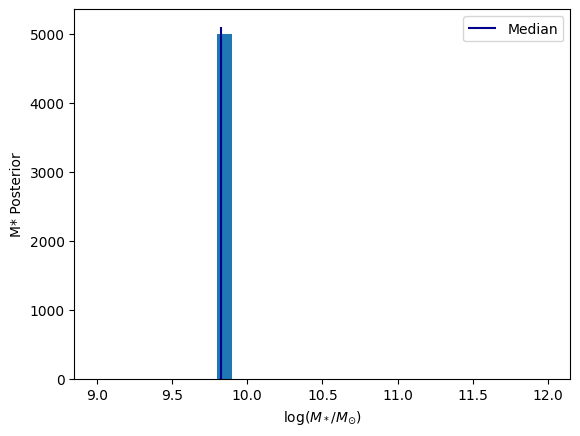

In [9]:
import matplotlib.pyplot as plt
n = plt.hist(np.log10(corrected_stellar_mass_posterior), range=(9, 12), bins=30)
plt.vlines(np.median(np.log10(corrected_stellar_mass_posterior)), ymin=0, ymax=np.max(n[0])+100, color='darkblue', label='Median')
plt.ylabel('M* Posterior')
plt.xlabel('$\log(M_* / M_{\odot})$')
plt.legend()

In [10]:
from prospect.models import transforms
def get_sfr(res, mod):
    agebins = mod.params['agebins']
    thetas = mod.theta_labels()                                                                                                                                           
    agebins_yrs = 10**agebins.T
    dt = agebins_yrs[1, :] - agebins_yrs[0, :]
    zfrac_idx = [i for i, s in enumerate(thetas) if 'z_fraction' in s]
    zfrac_chain = res['chain'][:,zfrac_idx[0]:zfrac_idx[-1]+1]
    
    total_mass_chain = res['chain'][:,thetas.index('logmass')]
    sfr_chain = []
    weights = results.get('weights',None) #likelihood values
    idx = np.argsort(weights)[-5000:]
    for i in idx:
        #this is the important part of this function -- it takes the proxy model parameters we sampled
        # and transforms them into the masses formed in each timebin
        # from there, we just divide these masses by the time in each bin to get the SFR in each bin
        masses_chain = transforms.zfrac_to_masses(10**total_mass_chain[i], zfrac_chain[i], agebins)
        sfr = masses_chain / dt                                                                                                                                  
        sfr_chain.append(sfr[0])                                                                                                                                                
    return sfr_chain

In [11]:
model_sfr = get_sfr(results, model)

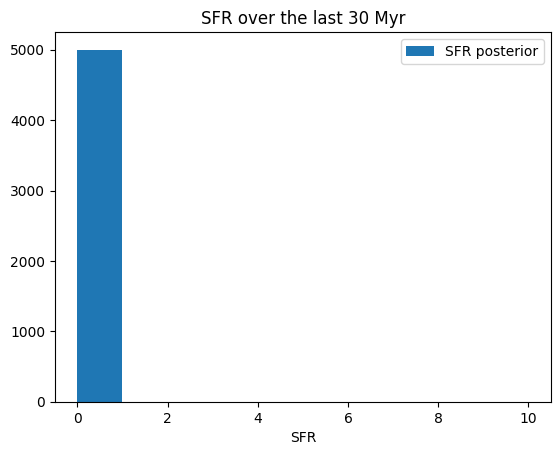

In [12]:
#now plot model SFR histogram

n, _, _ = plt.hist(model_sfr, range=(0,10), label='SFR posterior')
plt.title('SFR over the last 30 Myr')
plt.xlabel('SFR')
plt.legend()

In [13]:
import pandas as pd
data = {'log(M$_*$/M$_{\odot}$)\n': np.log10(corrected_stellar_mass_posterior),
       'log(Z$_*$/Z$_{\odot}$)\n': results['chain'][idx,model_params.index('logzsol')],
       'log(SFR)\n': np.log10(model_sfr),
       'A$_V$\n': results['chain'][idx,model_params.index('dust2')]}
        
df = pd.DataFrame(data)

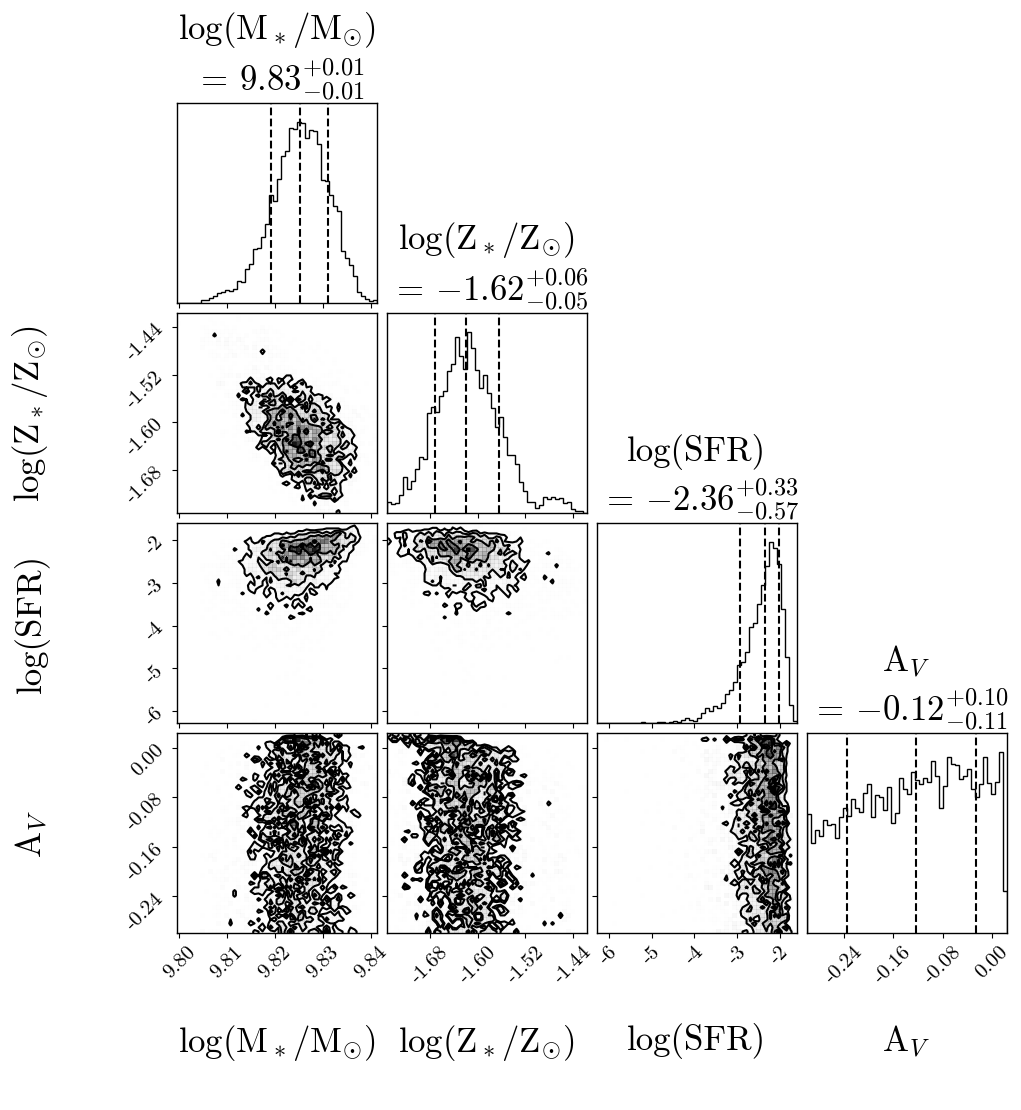

In [14]:
import plotfancy as pf
pf.housestyle_rcparams()
import corner
figure = corner.corner(df,labels=list(data.keys()),
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=True, title_kwargs={"fontsize": 25}, label_kwargs={'fontsize': 25}, labelpad=0.15,
                      bins=50,plot_datapoints=False)

In [15]:
model_sfr

[np.float64(0.002086575552318845),
 np.float64(0.0014570277670155783),
 np.float64(0.007658542488696714),
 np.float64(0.001400719014840103),
 np.float64(0.010978721844252779),
 np.float64(0.004685692082516606),
 np.float64(0.001704503001930981),
 np.float64(0.008855700110123505),
 np.float64(8.218321706156399e-05),
 np.float64(0.005446292387988994),
 np.float64(0.005177869606075811),
 np.float64(0.0072621615656228876),
 np.float64(0.00019952329755910914),
 np.float64(0.004272888495120197),
 np.float64(0.00864356751078075),
 np.float64(0.0037231251278120013),
 np.float64(0.0005786118323092968),
 np.float64(0.004153133573144279),
 np.float64(0.004703042923950098),
 np.float64(0.005520068225517571),
 np.float64(0.006108795780199176),
 np.float64(0.004406455166332184),
 np.float64(0.0013475705104999886),
 np.float64(0.0008081551161902338),
 np.float64(0.005982075656616238),
 np.float64(0.00495101994129215),
 np.float64(0.005625690405769871),
 np.float64(0.0013837433793071903),
 np.float64(

In [16]:
# from plot_sfh import plot_sfh
# plot_sfh('test001_fit.h5')

In [18]:
results['chain']

array([[-0.13872731,  0.64031029, 12.60773279, ...,  0.9025641 ,
        -2.18585402, -4.11188519],
       [ 0.0699017 ,  0.05144956, -6.36178834, ...,  0.93729876,
        -0.58829783, -0.58779728],
       [ 0.04207293,  0.73697487,  7.83487969, ...,  0.26244796,
        -1.62176863, -1.03432245],
       ...,
       [-0.09037097,  0.73147217, 14.53938019, ...,  0.92442709,
        -1.36419482, -2.25789269],
       [-0.09550559,  0.08100953,  6.90596154, ...,  0.90946755,
        -1.87589758, -0.73070038],
       [-0.15706516,  0.97039205,  6.09131387, ...,  0.94706702,
        -2.50608049, -3.94354463]], shape=(31981, 17))

In [19]:
def get_manual_model_params(nparams):
    """
    Reconstructs model parameters that are missing from the HDF5 file.
    """
    # --- Define theta_labels manually ---
    # This order must match the order of free parameters in your build_model function
    nbins = 10
    z_fraction_labels = [f"z_fraction_{i}" for i in range(nbins - 1)]
    theta_labels = (['dust2', 'duste_gamma', 'duste_umin', 'duste_qpah', 
                     'logmass', 'logzsol'] + 
                    z_fraction_labels + 
                    ['gas_logz', 'gas_logu'])

    # --- Reconstruct agebins ---
    tuniv = 14.  # Gyr, age at z=0
    tbinmax = (tuniv * 0.8) * 1e9
    lim1, lim2 = 7.0, 8.0  # 10 Myr and 100 Myr
    agelims = [0, lim1] + np.linspace(lim2, np.log10(tbinmax), nbins - 2).tolist() + [np.log10(tuniv * 1e9)]
    agebins = np.array([agelims[:-1], agelims[1:]])

    # --- Set redshift ---
    # This is from your test_for_sed.csv for the first object
    zred = 0.20275

    # --- Sanity Check ---
    # Ensure the number of labels matches the number of parameters in the chain
    if len(theta_labels) != nparams:
        raise ValueError(
            f"Mismatch in parameter count! The HDF5 file has {nparams} free parameters, "
            f"but the manually defined 'theta_labels' has {len(theta_labels)}. "
            "Please check the 'get_manual_model_params' function in this script "
            "and ensure it matches the free parameters in 'run_prosp_nonparaSFH.py'."
        )

    return theta_labels, agebins, zred

Plot saved to sfh_plot.png


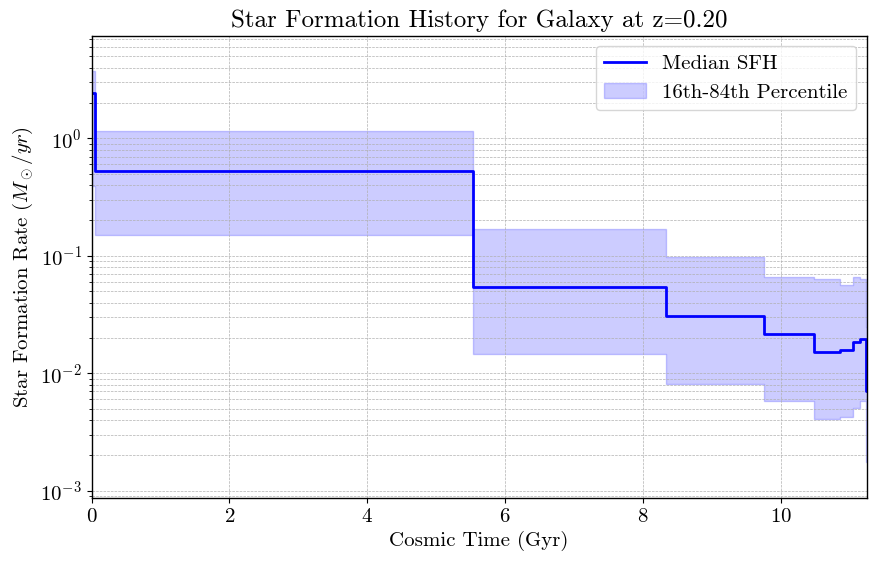

In [49]:
theta_labels,agebins,zred = get_manual_model_params(17)

flatchain = results['chain']
if flatchain.size == 0:
    print(f"Error: The chain in {results_file} is empty even when loaded with pread.")
# --- Get Model Info ---

# --- Process Posteriors ---
logmass_idx = theta_labels.index('logmass')
z_fraction_indices = [i for i, label in enumerate(theta_labels) if 'z_fraction' in label]

# --- Calculate SFR for each posterior sample ---
all_sfrs = []
for sample in flatchain:
    logmass_sample = sample[logmass_idx]
    z_fraction_sample = sample[z_fraction_indices]
    
    masses = zfrac_to_masses_log(logmass=logmass_sample, z_fraction=z_fraction_sample, agebins=agebins.T)
    bin_durations = 10**agebins[1] - 10**agebins[0]
    sfr = masses / bin_durations
    all_sfrs.append(sfr)

all_sfrs = np.array(all_sfrs)

# --- Convert to Cosmic Time ---
from astropy.cosmology import Planck18 as cosmo

lookback_time_bins = 10**agebins / 1e9
t_universe_at_z = cosmo.age(zred).value
cosmic_time_bins = t_universe_at_z - lookback_time_bins

# --- Calculate Percentiles ---
sfr_percentiles = np.percentile(all_sfrs, [16, 50, 84], axis=0)
sfr_16, sfr_50, sfr_84 = sfr_percentiles

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

plot_time = np.insert(cosmic_time_bins[1, :], 0, cosmic_time_bins[0, 0])
plot_sfr_50 = np.insert(sfr_50, 0, sfr_50[0])

ax.step(plot_time, plot_sfr_50, where='pre', color='blue', lw=2, label='Median SFH')

ax.fill_between(plot_time, np.insert(sfr_16, 0, sfr_16[0]), np.insert(sfr_84, 0, sfr_84[0]), 
                step='pre', color='blue', alpha=0.2, label='16th-84th Percentile')

ax.set_xlabel('Cosmic Time (Gyr)')
ax.set_ylabel(r'Star Formation Rate ($M_\odot / yr$)')
ax.set_title(f'Star Formation History for Galaxy at z={zred:.2f}')
ax.set_yscale('log')
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.set_xlim(0, t_universe_at_z)
if np.any(sfr_16 > 0):
    ax.set_ylim(bottom=np.min(sfr_16[sfr_16 > 0]) / 2, top=np.max(sfr_84) * 2)

plt.savefig('sfh_plot.png', dpi=300)
print("Plot saved to sfh_plot.png")


In [44]:
agebins

array([[ 0.        ,  7.        ,  8.        ,  8.29274543,  8.58549086,
         8.8782363 ,  9.17098173,  9.46372716,  9.75647259, 10.04921802],
       [ 7.        ,  8.        ,  8.29274543,  8.58549086,  8.8782363 ,
         9.17098173,  9.46372716,  9.75647259, 10.04921802, 10.14612804]])

In [47]:
agebins.T

array([[ 0.        ,  7.        ],
       [ 7.        ,  8.        ],
       [ 8.        ,  8.29274543],
       [ 8.29274543,  8.58549086],
       [ 8.58549086,  8.8782363 ],
       [ 8.8782363 ,  9.17098173],
       [ 9.17098173,  9.46372716],
       [ 9.46372716,  9.75647259],
       [ 9.75647259, 10.04921802],
       [10.04921802, 10.14612804]])

In [35]:
len(model.fixed_params+model.free_params)

20